In [1]:
import sys
import time

sys.path.insert(0, "../..")


from pycwb.modules.read_data.data_check import check_and_resample
from pycwb.config import Config
from pycwb.modules.logger import logger_init
from wdm_wavelet.wdm import WDM as WDMWavelet
from pycwb.types.time_frequency_series import TimeFrequencyMap

logger_init()

config = Config()
config.load_from_yaml('./user_parameters_injection.yaml')
config.nproc = 1

import pickle

# load the conditioned strains and nRMS from the previous run
with open("conditioned_strains.pkl", "rb") as f:
    data = pickle.load(f)
    strains = data["strains"]
    nRMS = data["nRMS"]

from pycwb.types.time_series import TimeSeries

normalized_strains = [TimeSeries.from_input(strain) for strain in strains]

Welcome to JupyROOT 6.26/10
Loading wavelet library
Trying to load wavelet library from /Users/yumengxu/miniforge3/envs/pycwb_x64/lib/python3.11/site-packages/lib/wavelet.so




/Users/yumengxu/miniforge3/envs/pycwb_x64/lib/python3.11/site-packages/ROOT/_facade.py:153: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  return _orig_ihook(name, *args, **kwds)


26-02-24 18:19:34 - logger_init - INFO - Logging initialized
26-02-24 18:19:34 - logger_init - INFO - Logging level: INFO
26-02-24 18:19:34 - logger_init - INFO - Logging file: None
26-02-24 18:19:34 - check_MRA_catalog - INFO - Checking MRA catalog
26-02-24 18:19:35 - load_MRA - INFO - Loading catalog of WDM cross-talk coefficients: /Users/yumengxu/Project/Physics/cwb/pyBurst/tests/sample/wdmXTalk/OverlapCatalog16-1024.bin


In [2]:
up_n = int(config.rateANA / 1024)
if up_n < 1:
    up_n = 1

i = 0
# print level infos
level = config.l_high - i
layers = 2 ** level if level > 0 else 0
rate = config.rateANA // 2 ** level

wdm_layers = max(1, layers)
wdm_wavelet = WDMWavelet(
    M=wdm_layers,
    K=wdm_layers,
    beta_order=config.WDM_beta_order,
    precision=config.WDM_precision,
)

26-02-24 18:19:35 - _make_tpu_driver_client - INFO - Remote TPU is not linked into jax; skipping remote TPU.
26-02-24 18:19:35 - backends - INFO - Unable to initialize backend 'tpu_driver': Could not initialize backend 'tpu_driver'
26-02-24 18:19:35 - backends - INFO - Unable to initialize backend 'cuda': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
26-02-24 18:19:35 - backends - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
26-02-24 18:19:35 - backends - INFO - Unable to initialize backend 'tpu': module 'jaxlib.xla_extension' has no attribute 'get_tpu_client'
26-02-24 18:19:35 - backends - INFO - Unable to initialize backend 'plugin': xla_extension has no attributes named get_plugin_device_client. Compile TensorFlow with //tensorflow/compiler/xla/python:enable_plugin_device set to true (defaults to false) to enable this.


In [4]:
tf_maps = [
    TimeFrequencyMap.from_timeseries(
        ts=strain,
        wavelet=wdm_wavelet,
        is_whitened=True,
        f_low=getattr(config, "fLow", None),
        f_high=getattr(config, "fHigh", None),
        edge=getattr(config, "segEdge", None),
    )
    for strain in normalized_strains
]

logger_info = "level : %d\t rate(hz) : %d\t layers : %d\t df(hz) : %f\t dt(ms) : %f \n" % (
        level, rate, layers, config.rateANA / 2. / (2 ** level), 1000. / rate)

from pycwb.modules.cwb_coherence.lag_plan import build_lag_plan_from_config
from pycwb.modules.cwb_coherence.coherence import max_energy

alp = 0.0

max_delay = config.max_delay
pattern = config.pattern
lag_plan = build_lag_plan_from_config(config, tf_maps)
n_lag = lag_plan.n_lag
print("lag plan built with %d lags" % n_lag)

for n, tf_map in enumerate(tf_maps):
    alp += max_energy(
        tf_map=tf_map,
        max_delay=max_delay,
        up_n=up_n,
        pattern=pattern,
        f_low=config.fLow,
        f_high=config.fHigh,
    )

logger_info += "max energy in units of noise variance: %g \n" % alp
print(logger_info)

lag plan built with 1 lags
level : 10	 rate(hz) : 2	 layers : 1024	 df(hz) : 1.000000	 dt(ms) : 500.000000 
max energy in units of noise variance: 0 



In [22]:
import sys
import time
sys.path.insert(0, "../..")

from pycwb.modules.read_data.data_check import check_and_resample
from pycwb.config import Config
from pycwb.modules.logger import logger_init
import numpy as np

logger_init()

config = Config()
config.load_from_yaml('./user_parameters_injection.yaml')
config.nproc = 1

from pycwb.modules.read_data import generate_injection, generate_noise_for_job_seg
from pycwb.modules.job_segment import create_job_segment_from_config

job_segments = create_job_segment_from_config(config)

data = generate_noise_for_job_seg(job_segments[0], config.inRate, f_low=config.fLow)
data = generate_injection(config, job_segments[0], data)

from pycwb.modules.data_conditioning.data_conditioning_python import data_conditioning
from pycwb.modules.data_conditioning import data_conditioning as data_conditioning_cwb


data = [check_and_resample(data[i], config, i) for i in range(len(job_segments[0].ifos))]

strains, nRMS = data_conditioning(config, data)
strains_cwb, nRMS_cwb = data_conditioning_cwb(config, data)


# single level cwb coherence
from pycwb.modules.coherence import coherence_single_res
from wdm_wavelet.wdm import WDM as WDMWavelet
from pycwb.types.time_frequency_series import TimeFrequencyMap
from pycwb.types.time_series import TimeSeries
strains = [TimeSeries.from_input(strain.data) for strain in strains_cwb]

up_n = int(config.rateANA / 1024)
if up_n < 1:
    up_n = 1

i = 0
# print level infos
level = config.l_high - i
layers = 2 ** level if level > 0 else 0
rate = config.rateANA // 2 ** level


# cWB2G coherence
print("======== cWB2G coherence =======")
# at run time output
from time import perf_counter
from pycwb.types.network import Network
from pycwb.modules.cwb_conversions import convert_to_wavearray, convert_netcluster_to_fragment_clusters, WSeries_to_matrix
from pycwb.modules.multi_resolution_wdm import create_wdm_for_level

timer_start = perf_counter()
wdm = create_wdm_for_level(config, config.WDM_level[i])

logger_info = "level : %d\t rate(hz) : %d\t layers : %d\t df(hz) : %f\t dt(ms) : %f \n" % (
        level, rate, layers, config.rateANA / 2. / (2 ** level), 1000. / rate)

net = Network(config, strains_cwb, nRMS_cwb, silent=True)
# produce TF maps with max over the sky energy
alp = 0.0

# FIXME: max time delay is different to pycbc
config.max_delay = net.get_max_delay()

print("Network %d lags" % net.nLag)

for n in range(len(config.ifo)):
    ts = convert_to_wavearray(strains_cwb[n])
    ts.Edge = config.segEdge
    # TODO: WSeries.putLayer is updated internally, here requires the wave packet pattern
    # https://gwburst.gitlab.io/documentation/latest/html/running.html#wave-packet-parameters
    # The max function is not just calculate the max values, but also set the whole TF map to
    # the max value over delayed time series, this is the most time consuming part in coherence
    alp += net.get_ifo(n).getTFmap().maxEnergy(ts, wdm.wavelet, config.max_delay, up_n, net.pattern)
    net.get_ifo(n).getTFmap().setlow(config.fLow)
    net.get_ifo(n).getTFmap().sethigh(config.fHigh)

timer_end = perf_counter()
tf_map_0 = WSeries_to_matrix(net.get_ifo(0).getTFmap())

logger_info += "max energy in units of noise variance: %g \n" % alp
print(logger_info)
print("max energy in tf map: %g \n" % np.max(tf_map_0))
print("shape of tf map: %s \n" % str(tf_map_0.shape))
print("cWB2G coherence calculation time: %.2f seconds\n" % (timer_end - timer_start))
# pycwb native coherence

print("======== pycwb native coherence =======")
from pycwb.modules.cwb_coherence.lag_plan import build_lag_plan_from_config
from pycwb.modules.cwb_coherence.coherence import max_energy

timer_start = perf_counter()
normalized_strains = [TimeSeries.from_input(strain) for strain in strains]

wdm_layers = max(1, layers)
wdm_wavelet = WDMWavelet(
    M=wdm_layers,
    K=wdm_layers,
    beta_order=config.WDM_beta_order,
    precision=config.WDM_precision,
)

tf_maps = [
    TimeFrequencyMap.from_timeseries(
        ts=strain,
        wavelet=wdm_wavelet,
        is_whitened=True,
        f_low=getattr(config, "fLow", None),
        f_high=getattr(config, "fHigh", None),
        edge=getattr(config, "segEdge", None),
    )
    for strain in normalized_strains
]

logger_info = "level : %d\t rate(hz) : %d\t layers : %d\t df(hz) : %f\t dt(ms) : %f \n" % (
        level, rate, layers, config.rateANA / 2. / (2 ** level), 1000. / rate)

alp = 0.0

max_delay = config.max_delay
pattern = config.pattern
lag_plan = build_lag_plan_from_config(config, tf_maps)
n_lag = lag_plan.n_lag
print("lag plan built with %d lags" % n_lag)

for n, tf_map in enumerate(tf_maps):
    alp += max_energy(
        tf_map=tf_map,
        max_delay=max_delay,
        up_n=up_n,
        pattern=pattern,
        f_low=config.fLow,
        f_high=config.fHigh,
    )

logger_info += "max energy in units of noise variance: %g \n" % alp
print(logger_info)
print("max energy in tf map: %g \n" % np.max(tf_maps[0].data))
print("shape of tf map: %s \n" % str(tf_maps[0].data.shape))
timer_end = perf_counter()
print("pycwb native coherence calculation time: %.2f seconds\n" % (timer_end - timer_start))

print("======== compare =======")

# Compare the two coherence results
print("cWB2G max energy: %g" % np.max(tf_map_0))
print("pycwb native max energy: %g" % np.max(tf_maps[0].data))
print("cWB2G shape: %s" % str(tf_map_0.shape))
print("pycwb native shape: %s" % str(tf_maps[0].data.shape))
# difference in max energy should be small, but can be different due to different wavelet implementations and numerical precision
# if shape is the same
if tf_map_0.shape == tf_maps[0].data.shape:
    max_energy_diff = abs(np.max(tf_map_0) - np.max(tf_maps[0].data))
    print("max energy difference: %g" % max_energy_diff)
else:
    print("max energy difference: N/A due to different shape")

26-02-24 21:00:27 - logger_init - INFO - Logging initialized
26-02-24 21:00:27 - logger_init - INFO - Logging level: INFO
26-02-24 21:00:27 - logger_init - INFO - Logging file: None
26-02-24 21:00:27 - check_MRA_catalog - INFO - Checking MRA catalog
26-02-24 21:00:27 - load_MRA - INFO - Loading catalog of WDM cross-talk coefficients: /Users/yumengxu/Project/Physics/cwb/pyBurst/tests/sample/wdmXTalk/OverlapCatalog16-1024.bin
26-02-24 21:00:27 - create_job_segment_from_config - INFO - --------------------------------------------------------------------------------
26-02-24 21:00:27 - create_job_segment_from_config - INFO - Initializing job segments
live time 1200.0
26-02-24 21:00:27 - get_job_list - INFO - lost livetime after building of the standard job list = 0 sec
26-02-24 21:00:27 - job_segment_from_dq - INFO - Number of job segments = 1
26-02-24 21:00:27 - generate_injection_list_from_config - INFO - Setting random seed to 150914 for injection generation reproducibility
26-02-24 21:

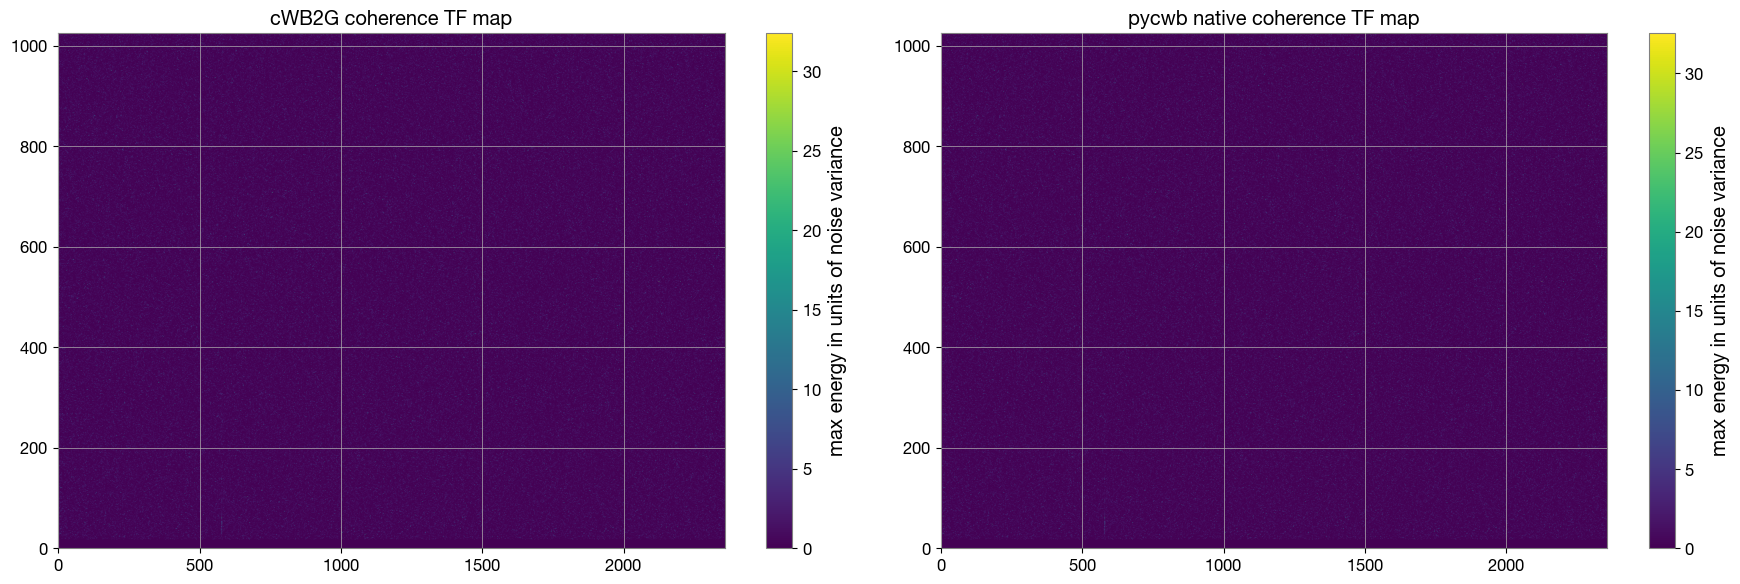

In [23]:
%matplotlib inline
import matplotlib.pyplot as plt 

plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
plt.title("cWB2G coherence TF map")
plt.imshow(tf_map_0, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label='max energy in units of noise variance')
plt.subplot(1, 2, 2)
plt.title("pycwb native coherence TF map")
plt.imshow(tf_maps[0].data, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label='max energy in units of noise variance')
plt.tight_layout()
plt.show()

Percentage of pixels above threshold in cWB2G: 10.01%
Percentage of pixels above threshold in pycwb: 9.81%


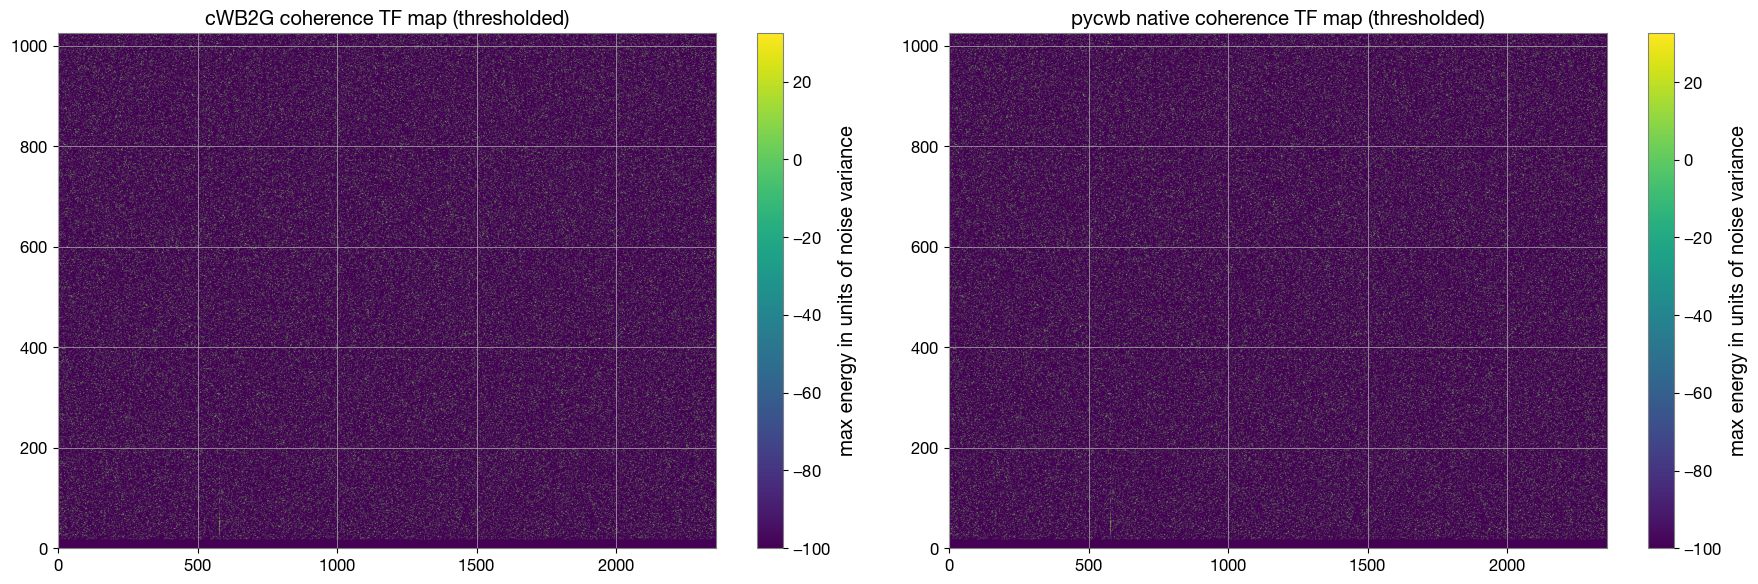

In [24]:
%matplotlib inline
import matplotlib.pyplot as plt 

# set the energy below a threshold to 0 for better visualization
threshold = 0.05 * max(np.max(tf_map_0), np.max(tf_maps[0].data))
tf_map_0_thresholded = np.where(tf_map_0 >= threshold, tf_map_0, -100)
tf_maps_0_thresholded = np.where(tf_maps[0].data >= threshold, tf_maps[0].data, -100)  
# print the percentage of pixels above the threshold
percent_above_threshold_cwb2g = np.sum(tf_map_0 >= threshold) / tf_map_0.size * 100
percent_above_threshold_pycwb = np.sum(tf_maps[0].data >= threshold) / tf_maps[0].data.size * 100
print(f"Percentage of pixels above threshold in cWB2G: {percent_above_threshold_cwb2g:.2f}%")
print(f"Percentage of pixels above threshold in pycwb: {percent_above_threshold_pycwb:.2f}%")
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
plt.title("cWB2G coherence TF map (thresholded)")
plt.imshow(tf_map_0_thresholded, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label='max energy in units of noise variance')
plt.subplot(1, 2, 2)
plt.title("pycwb native coherence TF map (thresholded)")
plt.imshow(tf_maps_0_thresholded, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label='max energy in units of noise variance')
plt.tight_layout()
plt.show()  

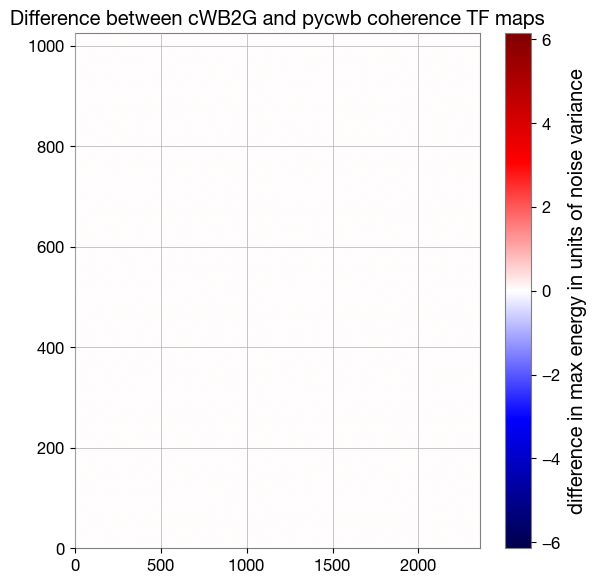

In [25]:
# plot the difference between the two TF maps
tf_map_diff = tf_map_0 - tf_maps[0].data
plt.figure(figsize=(6, 6))
plt.title("Difference between cWB2G and pycwb coherence TF maps")
plt.imshow(tf_map_diff, aspect='auto', origin='lower', cmap='seismic', vmin=-np.max(np.abs(tf_map_diff)), vmax=np.max(np.abs(tf_map_diff)))
plt.colorbar(label='difference in max energy in units of noise variance')
plt.tight_layout()
plt.show()

In [ ]:
tf_map_diff
# get non zero indexes in the difference map
non_zero_indexes = np.nonzero(tf_map_diff)
print("Number of non-zero pixels in the difference map: %d" % len(non_zero_indexes[0]))
# percentage of non-zero pixels in the difference map
percent_non_zero = len(non_zero_indexes[0]) / tf_map_diff.size * 100
print("Percentage of non-zero pixels in the difference map: %.2f%%" % percent_non_zero)
# number of pixels above a certain threshold in the difference map
threshold_diff = 0.01 * max(np.max(tf_map_0), np.max(tf_maps[0].data))
num_pixels_above_threshold_diff = np.sum(np.abs(tf_map_diff) >= threshold_diff)
print("Number of pixels with difference above threshold: %d" % num_pixels_above_threshold_diff)
print("Percentage of pixels with difference above threshold: %.2f%%" % (num_pixels_above_threshold_diff / tf_map_diff.size * 100))

Number of non-zero pixels in the difference map: 1190955
Percentage of non-zero pixels in the difference map: 49.28%
Number of pixels with difference above threshold: 6919
Percentage of pixels with difference above threshold: 0.29%
